In [1]:
from pilotpy.tools import *
import scanpy as sc
#from pilot_gm_vae import *

In [2]:
import os
desired_path = '/data/scRNA/To_Mehdi/Emilia/flex' # Or the folder your current notebook is in
os.chdir(desired_path)

In [4]:
file_path = 'hu_kidney.h5ad'
hs_snrna=sc.read_h5ad(file_path)

In [3]:
file_path = 'mu_adenine.h5ad'
mm_snrna=sc.read_h5ad(file_path)

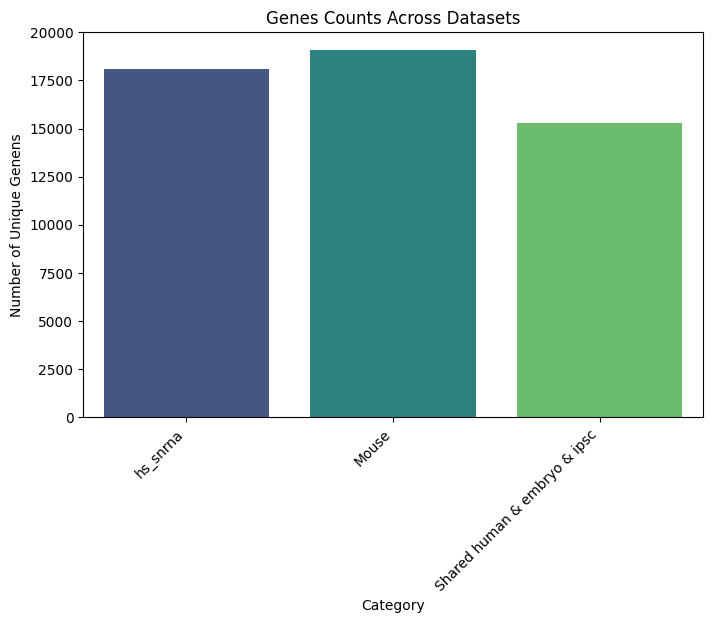

In [6]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming adata1, adata2, and adata3 are your AnnData objects
donors_1 = set(hs_snrna.var_names.str.upper())
donors_3 = set(mm_snrna.var_names.str.upper())

# Find shared donors
shared_12 = donors_1 & donors_3

# Count occurrences
counts = {
    "hs_snrna": len(donors_1),
     "Mouse": len(donors_3),


    "Shared human & embryo & ipsc": len(shared_12),
}

# Convert to DataFrame
df = pd.DataFrame(list(counts.items()), columns=["Category", "Count"])

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Category", y="Count", palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Unique Genens")
plt.title("Genes Counts Across Datasets")
plt.show()


In [7]:
hs_snrna.var_names=hs_snrna.var_names.str.upper()
mm_snrna.var_names=mm_snrna.var_names.str.upper()

In [9]:
hs_snrna_filtered = hs_snrna[:, list(shared_12)].copy()
mm_snrna_filtered = mm_snrna[:, list(shared_12)].copy()

In [22]:
hs_snrna_filtered.obs['Donor'] = hs_snrna_filtered.obs['Sample']
hs_snrna_filtered.obs['Dataset'] = 'human'

mm_snrna_filtered.obs['Donor'] = mm_snrna_filtered.obs['Sample']  
mm_snrna_filtered.obs['Dataset'] = 'Mouse'


In [24]:
donor_combined = np.concatenate([hs_snrna_filtered.obs['Donor'].values, mm_snrna_filtered.obs['Donor'].values])
status_combined = np.concatenate([hs_snrna_filtered.obs['eGFR'].values,mm_snrna_filtered.obs['category']])
Dataset = np.concatenate([hs_snrna_filtered.obs['Dataset'].values,mm_snrna_filtered.obs['Dataset'].values])
cell_combined = np.concatenate([hs_snrna_filtered.obs['annotation_highres'].values,mm_snrna_filtered.obs['annotation_highres'].values,])
idd = np.concatenate([hs_snrna_filtered.obs.index,mm_snrna_filtered.obs.index,])
hs_snrna_x = hs_snrna_filtered.layers['after_soupx'].toarray()  # Shape: (n_human_cells, n_genes)
mm_snrna_filtered_x = mm_snrna_filtered.layers['after_soupx'].toarray()  # Shape: (n_human_cells, n_genes)
X_genes_combined = np.concatenate([hs_snrna_x,mm_snrna_filtered_x], axis=0)

In [25]:
combined_adata = sc.AnnData(X_genes_combined)
combined_adata.obs['Donor'] = donor_combined
combined_adata.obs['status'] = status_combined
combined_adata.obs['Dataset'] = Dataset
combined_adata.obs['cell_subtype'] = cell_combined  
combined_adata.obs['index'] =idd
combined_adata.var_names=list(shared_12)
combined_adata.layers["counts"] = combined_adata.X.copy()

In [26]:
combined_adata.obs['Dataset'].unique()


array(['human', 'Mouse'], dtype=object)

In [27]:
combined_adata.write_h5ad('/data/scRNA/To_Mehdi/Emilia/flex/Integration_mouse_human.h5ad')

In [28]:
combined_adata

AnnData object with n_obs × n_vars = 215150 × 15262
    obs: 'Donor', 'status', 'Dataset', 'cell_subtype', 'index'
    layers: 'counts'